# Removal Rate 단계별 동작 분석

**`algorithm_new/Common/REMOVAL_RATE.py`** 의 실제 함수들을 그대로 호출하면서,  
각 회귀 계수(`b0`, `b1`, `weighted`, `current`, `if`)가 어떤 데이터로 만들어지는지 단계별로 확인합니다.

```
전체 흐름
────────────────────────────────────────────────────────────────────
 merge_df  +  Pre_Thk_VM 캐시
   │
   ├─ [준비]  load_pre_thk_data()   Pre_Thk_VM → _VM 컬럼 merge
   │          BIAS 계산              CMP 후 두께 편차
   │
   ├─ [Step 1] IDLE / Recipe 필터
   │           _detect_cycles()      소모품 급감 기준 pad cycle 번호 부여
   │
   ├─ [Step 2] eqp_model 루프
   │           RR = (Pre_Thk - Post_Thk) / Pol_Time
   │           6σ 이상치 제거
   │
   ├─ [Step 3] Quartile 커버리지 체크  → 4분위 각 25건 이상이어야 회귀 진행
   │
   ├─ [Step 4] _fit_lr()              전체 데이터 단순회귀  →  b1, b0
   │
   ├─ [Step 5] date × part 세그먼트   최근 구간 데이터 충분한지 판별
   │           _fit_weighted()        최근 구간 가중 회귀  →  b1_weighted, b0_weighted
   │
   ├─ [Step 6] _get_current_cycle()   현재 패드 사이클(cycle=1) 추출
   │           _fit_current()         12h 이내 & RR_Count 초과 시  →  b1_current, b0_current
   │
   └─ [Step 7] _fit_if()              PAD ≤ Pad_Seperation 구간 회귀  →  if_b1, if_b0
────────────────────────────────────────────────────────────────────
```

---
## 환경 설정

In [1]:
import sys, os
from pathlib import Path
from unittest.mock import MagicMock

ALGO_DIR = Path('..') / 'algorithm_new'
sys.path.insert(0, str(ALGO_DIR))
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = '1'

import pymongo as _pymongo
_cli = MagicMock()
_cli.__getitem__.return_value = MagicMock()
_cli.close.return_value = None
_pymongo.MongoClient = MagicMock(return_value=_cli)

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

try:
    matplotlib.rc('font', family='AppleGothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
COLORS = plt.cm.tab10.colors

print('✅ 환경 설정 완료')

✅ 환경 설정 완료


---
## 데이터 & 파라미터 로드

In [2]:
from Common.Get_Data import Get_data
from Common.REMOVAL_RATE import Removal_Rate_Get   # 실제 모듈 임포트

# ── Set-up 정보 ──────────────────────────────────────────────────────
mico = Get_data.baseinfoGetData(Family='DRAM', oper_desc='M1 CU CMP')
key  = mico.iloc[0]     # 단일 Set-up 행 (Series)

# ── 파라미터 추출 (compute_rr 내부와 동일) ───────────────────────────
APC_Para  = key['APC_Para']               # 'P3'
RR_Para   = key['RR_Para'].upper()        # 'PAD'
pol_type  = 3

Pol_Para  = Get_data.APCParaGet(APC_Para, pol_type)   # ['P3']
Head_Para = Get_data.HeadParaGet(APC_Para)             # 'AMAT_HEAD_1'
Pad_Para  = Get_data.PadParaGet(APC_Para)              # 'AMAT_PAD_3'
Disk_Para = Get_data.DiskParaGet(APC_Para)             # 'AMAT_DISK_3'

# RR_Para 에 따라 소모품 파라미터 결정
if   RR_Para == 'HEAD': consumable_Para = Head_Para
elif RR_Para == 'PAD' : consumable_Para = Pad_Para
elif RR_Para == 'DISK': consumable_Para = Disk_Para

Thk_Para     = key['Thk_Para']                    # 'AMAT_POST_OCD_AVG'
vm_col       = Thk_Para + '_VM'                   # Pre_Thk_VM 결과 컬럼
Pre_Target   = float(key['Pre_Target'])            # 2350 Å
Post_Target  = float(key['Target'])                # 1900 Å
RR_Weight    = float(key['RR_Weight'])             # 30  (최근 구간 가중치)
RR_Count     = float(key['RR_Count'])              # 50  (current cycle 최소 건수)
RR_Period    = key['RR_Period']                    # NaN (전체 현재 사이클 사용)
Pad_Seperation = key['Pad_Seperation']             # 3   (IF 모델 소모품 한계)

print('── Set-up 파라미터 ──────────────────────────────────')
print(f'  consumable_Para : {consumable_Para}  ← {RR_Para} 소모품')
print(f'  Pol_Para        : {Pol_Para}')
print(f'  Thk_Para        : {Thk_Para}  (vm_col={vm_col})')
print(f'  Pre_Target      : {Pre_Target} Å   Post_Target: {Post_Target} Å')
print(f'  RR_Weight       : {RR_Weight}  (최근 구간 반복 횟수)')
print(f'  RR_Count        : {RR_Count}  (current cycle 진입 최소 건수)')
print(f'  RR_Period       : {RR_Period}  (NaN = 전체 현재 사이클)')
print(f'  Pad_Seperation  : {Pad_Seperation}  (IF 모델 적용 소모품 한계)')

# 대표 장비/레시피 (단계별 상세 설명용)
DEMO_EQP = 'KCMP43'
DEMO_RCP = 'E2_M1CU_R12_TSV.CAS'
print(f'\n대표 장비: {DEMO_EQP} / {DEMO_RCP}')

── Set-up 파라미터 ──────────────────────────────────
  consumable_Para : AMAT_PAD_3  ← PAD 소모품
  Pol_Para        : ['P3']
  Thk_Para        : AMAT_POST_OCD_AVG  (vm_col=AMAT_POST_OCD_AVG_VM)
  Pre_Target      : 2350.0 Å   Post_Target: 1900.0 Å
  RR_Weight       : 30.0  (최근 구간 반복 횟수)
  RR_Count        : 50.0  (current cycle 진입 최소 건수)
  RR_Period       : None  (NaN = 전체 현재 사이클)
  Pad_Seperation  : 3  (IF 모델 적용 소모품 한계)

대표 장비: KCMP43 / E2_M1CU_R12_TSV.CAS


---
## 준비 — Pre_Thk_VM 로드 & BIAS 계산

```python
# REMOVAL_RATE.py  load_pre_thk_data()  (Excel 캐시 경로)
Pre_Thk_Table = pd.read_excel(cache_file)            # 어제 만든 엑셀
merge_df = pd.merge_asof(merge_df, Pre_Thk_Table,
                         on='Pre_Oper_Date', by=['pre_eq_ch'])
# → AMAT_POST_OCD_AVG_VM 컬럼이 merge_df에 추가됨

# Module.py  compute_removal_rate() 내부
merge_df['BIAS'] = merge_df[Thk_Para] - merge_df[Thk_Para_13P] - (Post_Target - Target_13P)
```

    [Excel 캐시] LC_M1_CU_CMP_M10.xlsx 로드
    → AMAT_POST_OCD_AVG_VM: 20844/20844 매칭
merge_rr: (20844, 54)
추가된 컬럼: vm_col=AMAT_POST_OCD_AVG_VM, AMAT_POST_OCD_AVG_Count
AMAT_POST_OCD_AVG_VM 통계: mean=1.13 Å  (Pre_Thk_VM 보정값)
BIAS 통계: mean=0.00 Å  (0이어야 정상)


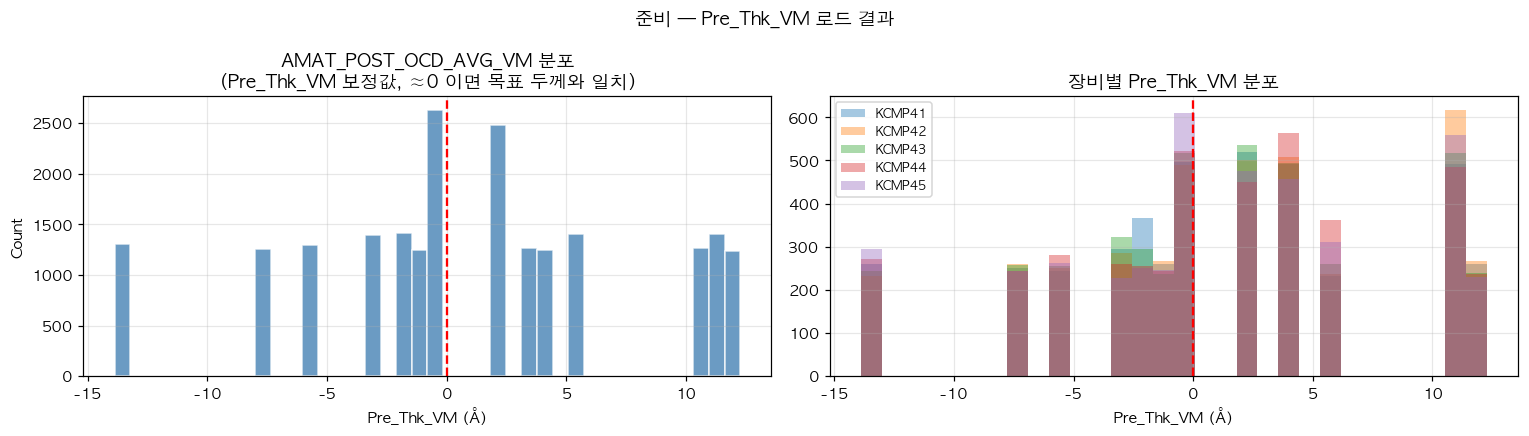

In [3]:
# ── CMP 실측 데이터 로드 ─────────────────────────────────────────────
merge_df = pd.read_csv(
    ALGO_DIR / 'merge_df_sample.csv',
    parse_dates=['Date', 'pre_oper_time']
)
merge_df['IDLE'] = merge_df['IDLE'].fillna('')

# ── load_pre_thk_data() 실제 함수 호출 ──────────────────────────────
merge_df_orig = merge_df.copy()  # compute_removal_rate에 원본 전달용
merge_rr = Removal_Rate_Get.load_pre_thk_data(merge_df, mico, 'url', 'db')

# ── BIAS 계산 (Module.py compute_removal_rate 내부와 동일) ──────────
Thk_Para_13P = mico[mico['FB_Type'] == 'TIME']['Thk_Para'].iloc[0]
Target_13P   = float(mico[mico['FB_Type'] == 'TIME']['Target'].iloc[0])
merge_rr['BIAS'] = (
    merge_rr[Thk_Para] - merge_rr[Thk_Para_13P]
) - (Post_Target - Target_13P)

print(f'merge_rr: {merge_rr.shape}')
print(f'추가된 컬럼: vm_col={vm_col}, AMAT_POST_OCD_AVG_Count')
print(f'{vm_col} 통계: mean={merge_rr[vm_col].mean():.2f} Å  (Pre_Thk_VM 보정값)')
print(f'BIAS 통계: mean={merge_rr["BIAS"].mean():.2f} Å  (0이어야 정상)')

# Pre_Thk_VM 적용 효과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('준비 — Pre_Thk_VM 로드 결과', fontsize=12, fontweight='bold')

ax = axes[0]
ax.hist(merge_rr[vm_col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_title(f'{vm_col} 분포\n(Pre_Thk_VM 보정값, ≈0 이면 목표 두께와 일치)')
ax.set_xlabel('Pre_Thk_VM (Å)')
ax.set_ylabel('Count')
ax.grid(alpha=0.3)

ax = axes[1]
for i, eqp in enumerate(sorted(merge_rr['eqp_id'].unique())):
    sub = merge_rr[merge_rr['eqp_id'] == eqp]
    ax.hist(sub[vm_col].dropna(), bins=30, alpha=0.4,
            color=COLORS[i], label=eqp)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_title('장비별 Pre_Thk_VM 분포')
ax.set_xlabel('Pre_Thk_VM (Å)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 1 — IDLE 필터 + `_detect_cycles()` : 패드 사이클 분리

```python
# compute_rr() 내부
temp_data = merge_df[
    (merge_df['operation_id'] == Oper_Code) &
    (merge_df['recipe_id']    == Recipe_ID) &
    ((merge_df['IDLE'] == '') | (merge_df['IDLE'].isna()))   # IDLE 제거
].copy()

# _detect_cycles() 내부
raw = (temp_data2[consumable_Para].diff() < -3).cumsum()    # 소모품 3 이상 급감 = 교체
temp_data2['cycle'] = raw.max() + 1 - raw                  # 최신=1, 오래될수록 숫자 증가
```

> **cycle 번호 규칙**: 현재 패드 = `cycle 1`, 이전 패드 순서대로 2, 3, 4 …  
> Pre_Thk_VM 의 `pad_cycle` 과 반대 방향임에 주의

In [4]:
# ── IDLE / Recipe 필터 (compute_rr 내부와 동일) ──────────────────────
temp_data = merge_rr[
    (merge_rr['operation_id'] == key['Oper_Code']) &
    (merge_rr['recipe_id']    == key['Recipe_ID']) &
    ((merge_rr['IDLE'] == '') | (merge_rr['IDLE'].isna()))
].copy()

print(f'필터 전: {len(merge_rr):,}행  →  필터 후: {len(temp_data):,}행')
print(f'  (Oper={key["Oper_Code"]}, Recipe={key["Recipe_ID"]}, IDLE 제거)')

# ── _detect_cycles() 실제 함수 호출 ─────────────────────────────────
temp_data3 = Removal_Rate_Get._detect_cycles(temp_data, consumable_Para)

print(f'\n_detect_cycles 후: {len(temp_data3):,}행')
print(f'cycle 번호 (1=현재 패드, 숫자 클수록 오래된 패드):')
for cyc in sorted(temp_data3['cycle'].unique()):
    n = len(temp_data3[temp_data3['cycle'] == cyc])
    pad_range = temp_data3[temp_data3['cycle']==cyc][consumable_Para]
    print(f'  cycle {cyc}: {n:4d}행  |  {consumable_Para}: {pad_range.min():.1f} ~ {pad_range.max():.1f}')

필터 전: 20,844행  →  필터 후: 5,200행
  (Oper=V5077000E, Recipe=E2_M1CU_R12_TSV.CAS, IDLE 제거)

_detect_cycles 후: 5,200행
cycle 번호 (1=현재 패드, 숫자 클수록 오래된 패드):
  cycle 1:  300행  |  AMAT_PAD_3: 0.1 ~ 10.0
  cycle 2: 1311행  |  AMAT_PAD_3: 0.1 ~ 23.9
  cycle 3: 1666행  |  AMAT_PAD_3: 0.1 ~ 24.3
  cycle 4: 1618행  |  AMAT_PAD_3: 0.1 ~ 23.9
  cycle 5:  305행  |  AMAT_PAD_3: 0.1 ~ 20.6


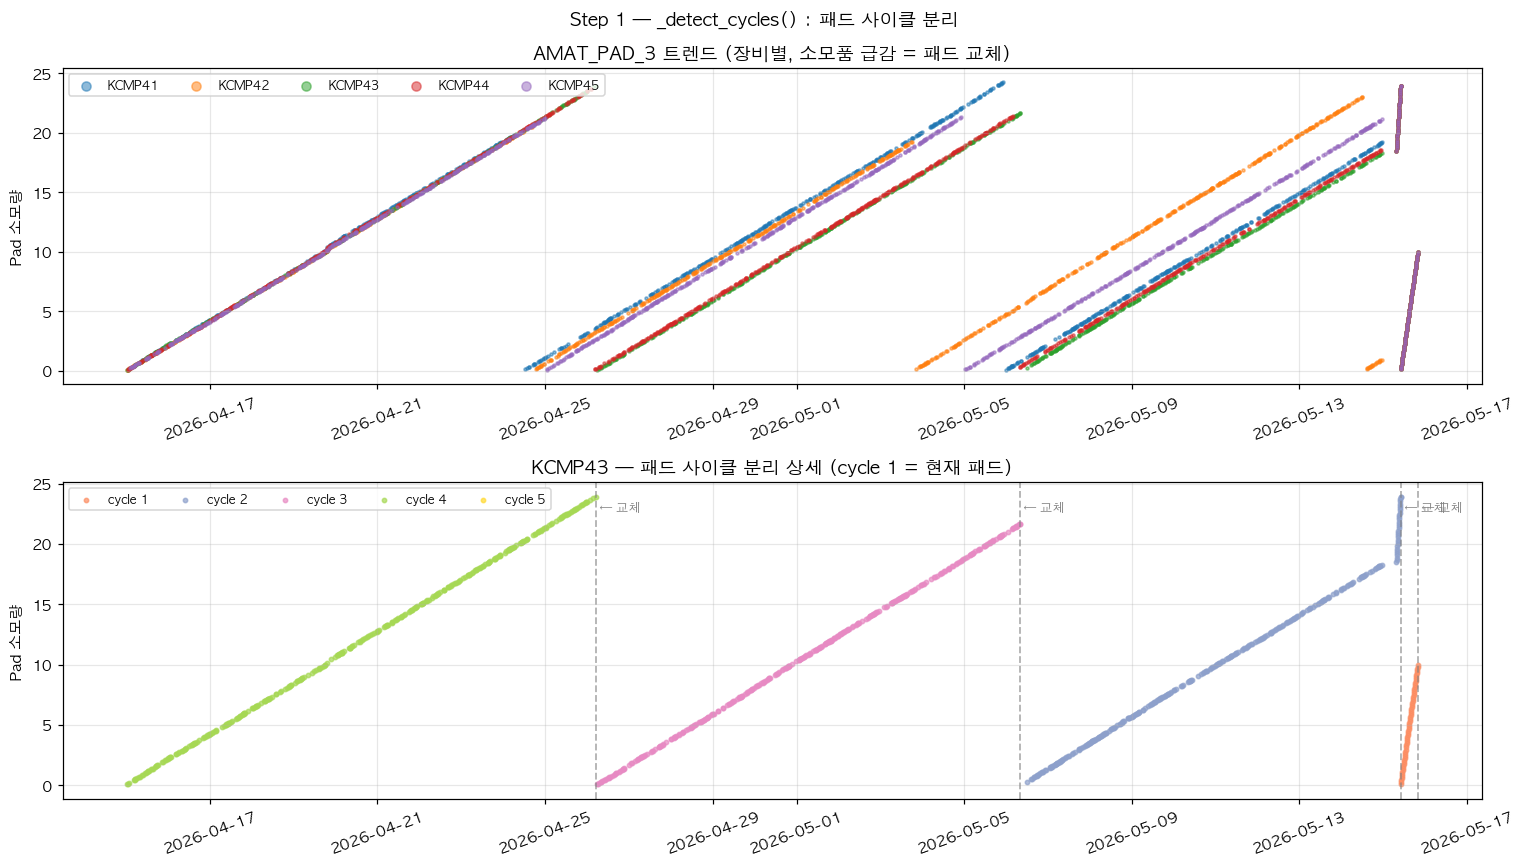

In [5]:
# ── 패드 사이클 시각화 (전체 장비) ───────────────────────────────────
eqp_list = sorted(temp_data3['eqp_id'].unique())
cycle_list = sorted(temp_data3['cycle'].unique())
cycle_colors = plt.cm.Set2.colors

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Step 1 — _detect_cycles() : 패드 사이클 분리', fontsize=12, fontweight='bold')

# ① 패드 소모량 트렌드 — 장비별 색상, 사이클별 마커
ax = axes[0]
for i, eqp in enumerate(eqp_list):
    sub = temp_data3[temp_data3['eqp_id'] == eqp].sort_values('Date')
    ax.scatter(sub['Date'], sub[consumable_Para], s=4, alpha=0.5,
               color=COLORS[i], label=eqp)
ax.set_title(f'{consumable_Para} 트렌드 (장비별, 소모품 급감 = 패드 교체)')
ax.set_ylabel('Pad 소모량')
ax.legend(markerscale=3, fontsize=8, ncol=5)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=20)

# ② 대표 장비 상세 — cycle별 색상
ax = axes[1]
demo3 = temp_data3[temp_data3['eqp_id'] == DEMO_EQP].sort_values('Date')
for cyc in cycle_list:
    c = demo3[demo3['cycle'] == cyc]
    ax.scatter(c['Date'], c[consumable_Para], s=8, alpha=0.7,
               color=cycle_colors[cyc % len(cycle_colors)], label=f'cycle {cyc}')

# 교체 시점 수직선
for cyc in cycle_list[:-1]:
    boundary = demo3[demo3['cycle'] == cyc]['Date'].max()
    ax.axvline(boundary, color='gray', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.text(boundary, demo3[consumable_Para].max() * 0.95,
            f' ← 교체', fontsize=8, color='gray')

ax.set_title(f'{DEMO_EQP} — 패드 사이클 분리 상세 (cycle 1 = 현재 패드)')
ax.set_ylabel('Pad 소모량')
ax.legend(fontsize=8, ncol=5)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---
## Step 2 — RR 계산 & 6σ 이상치 제거

```python
# _process_models() 내부
pre_thk  = Pre_Target + temp_data4[vm_col]          # 투입 전 두께 = 목표 + VM 보정
post_thk = temp_data4[Thk_Para]                     # 실측 CMP 후 두께

temp_data4['RR'] = (pre_thk - post_thk) / temp_data4['Pol_Time']
#                   ↑ 제거된 두께           ↑ 연마 시간(sec)
#  단위: Å/sec

# 6σ 이상치 제거
rr_avg = temp_data4['RR'].mean()
rr_std = temp_data4['RR'].std()
temp_data4 = temp_data4[(temp_data4['RR'] < rr_avg + rr_std*6)
                       & (temp_data4['RR'] > rr_avg - rr_std*6)]
```

In [6]:
# ── _process_models 내부 로직 그대로 재현 ──────────────────────────────
# (eqp_model 루프 1회 — 샘플 데이터는 eqp_model='REFLEXION_LK' 단일)

x = temp_data3['eqp_model'].unique()[0]
temp_data4 = temp_data3[temp_data3['eqp_model'] == x].copy()

# 소모품 범위 계산 (quartile 기준점)
part_max = temp_data4[consumable_Para].max()
part_min = temp_data4[consumable_Para].min()
part_1q  = part_min + (part_max - part_min) / 4
part_2q  = part_min + (part_max - part_min) / 2
part_3q  = part_min + (part_max - part_min) * 3 / 4

# 필요 컬럼만 선택
col_list = (['Date', 'substrate_id', 'eqp_id', 'recipe_id', 'process_id',
             Pad_Para, Head_Para, Disk_Para, 'pre_eq_ch',
             vm_col, Thk_Para, 'cycle', 'BIAS'] + Pol_Para)
temp_data4 = temp_data4[[c for c in col_list if c in temp_data4.columns]].copy()
temp_data4.drop_duplicates(inplace=True)

# Pol_Time 계산
temp_data4['Pol_Time'] = temp_data4[Pol_Para].sum(axis=1)
temp_data4.dropna(axis=0, subset=[Thk_Para, consumable_Para], inplace=True)
temp_data4.drop(temp_data4[temp_data4['Pol_Time'] == 0].index, inplace=True)
temp_data4.fillna(value={vm_col: 0}, inplace=True)

# ── RR 계산 ──────────────────────────────────────────────────────────
pre_thk  = Pre_Target + temp_data4[vm_col]   # 투입 전 두께 = 목표 + VM 보정
post_thk = temp_data4[Thk_Para]              # 실측 CMP 후 두께

temp_data4['RR'] = (pre_thk - post_thk) / temp_data4['Pol_Time']

# ── eq_recipe 키 구성 ─────────────────────────────────────────────────
temp_data4['eq_recipe'] = temp_data4['eqp_id'] + '//' + temp_data4['recipe_id']

# ── 6σ 이상치 제거 ───────────────────────────────────────────────────
rr_avg = temp_data4['RR'].mean()
rr_std = temp_data4['RR'].std()
before_n = len(temp_data4)
temp_data4 = temp_data4[
    (temp_data4['RR'] < rr_avg + rr_std * 6) &
    (temp_data4['RR'] > rr_avg - rr_std * 6)
].copy()

print(f'RR 계산 완료: {before_n:,}행  →  6σ 필터 후: {len(temp_data4):,}행')
print(f'RR 통계: mean={rr_avg:.3f} Å/sec  |  std={rr_std:.3f}  |  6σ범위: [{rr_avg-6*rr_std:.2f}, {rr_avg+6*rr_std:.2f}]')
temp_data4[['Date','eqp_id','recipe_id','cycle',consumable_Para,'Pol_Time',vm_col,Thk_Para,'RR']].head(5)

RR 계산 완료: 5,200행  →  6σ 필터 후: 5,197행
RR 통계: mean=19.435 Å/sec  |  std=4.107  |  6σ범위: [-5.20, 44.07]


,Date,eqp_id,recipe_id,cycle,AMAT_PAD_3,Pol_Time,AMAT_POST_OCD_AVG_VM,AMAT_POST_OCD_AVG,RR
0,2026-04-15 00:41:55,KCMP43,E2_M1CU_R12_TSV.CAS,4,0.0843,24.187,1.877385,1932.8820,17.323165
1,2026-04-15 00:52:50,KCMP43,E2_M1CU_R12_TSV.CAS,4,0.0975,26.340,11.332395,1903.2829,17.389882
2,2026-04-15 01:36:36,KCMP43,E2_M1CU_R12_TSV.CAS,4,0.1643,21.679,1.877385,1937.9704,19.092531
3,2026-04-15 04:20:03,KCMP43,E2_M1CU_R12_TSV.CAS,4,0.4028,24.591,2.448200,1868.4324,19.682640
4,2026-04-15 04:53:46,KCMP43,E2_M1CU_R12_TSV.CAS,4,0.4432,22.441,-5.510217,1907.3430,19.479826


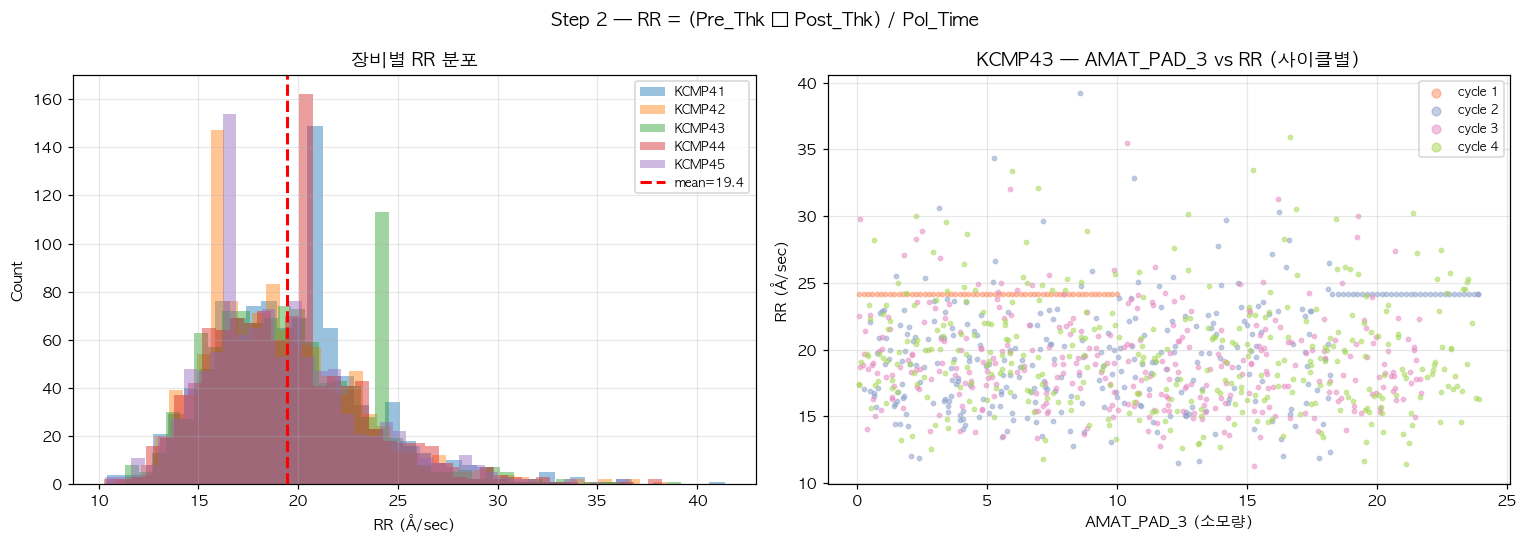

In [7]:
# ── RR 트렌드 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 2 — RR = (Pre_Thk − Post_Thk) / Pol_Time', fontsize=12, fontweight='bold')

# ① 전체 장비 RR 분포
ax = axes[0]
eqp_list4 = sorted(temp_data4['eqp_id'].unique())
for i, eqp in enumerate(eqp_list4):
    sub = temp_data4[temp_data4['eqp_id'] == eqp]
    ax.hist(sub['RR'], bins=40, alpha=0.45, color=COLORS[i], label=eqp)
ax.axvline(rr_avg, color='red', linewidth=2, linestyle='--', label=f'mean={rr_avg:.1f}')
ax.set_title('장비별 RR 분포')
ax.set_xlabel('RR (Å/sec)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ② 대표 장비: PAD 소모 vs RR (사이클별 색상)
ax = axes[1]
demo4 = temp_data4[temp_data4['eqp_id'] == DEMO_EQP].sort_values(consumable_Para)
for cyc in sorted(demo4['cycle'].unique()):
    c = demo4[demo4['cycle'] == cyc]
    ax.scatter(c[consumable_Para], c['RR'], s=8, alpha=0.5,
               color=cycle_colors[cyc % len(cycle_colors)], label=f'cycle {cyc}')
ax.set_title(f'{DEMO_EQP} — {consumable_Para} vs RR (사이클별)')
ax.set_xlabel(f'{consumable_Para} (소모량)')
ax.set_ylabel('RR (Å/sec)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 3 — Quartile 커버리지 체크

회귀를 진행하기 전에 **패드 소모량을 4등분(Q1~Q4)** 하여 각 구간에 데이터가 25건 이상인지 확인합니다.  
데이터가 한쪽 구간에 몰려있으면 회귀계수의 신뢰도가 낮아지기 때문입니다.

```python
# _process_models() 내부
quartile_counts = pd.cut(
    temp_data5[consumable_Para],
    bins=[part_min, part_1q, part_2q, part_3q, part_max],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
).value_counts()

if (quartile_counts > 25).all():   # ← 모든 구간 25건 이상이어야 회귀 진행
    b1, b0 = _fit_lr(...)
    ...
```

In [8]:
# ── 대표 장비 Quartile 커버리지 확인 ────────────────────────────────
iter_val = f'{DEMO_EQP}//{DEMO_RCP}'
temp_data5 = temp_data4[temp_data4['eq_recipe'] == iter_val].copy()

quartile_counts = pd.cut(
    temp_data5[consumable_Para],
    bins=[part_min, part_1q, part_2q, part_3q, part_max],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
).value_counts()

print(f'{DEMO_EQP} / {DEMO_RCP}')
print(f'소모품 범위: {part_min:.1f} ~ {part_max:.1f}')
print(f'  Q1: {part_min:.1f} ~ {part_1q:.1f}')
print(f'  Q2: {part_1q:.1f} ~ {part_2q:.1f}')
print(f'  Q3: {part_2q:.1f} ~ {part_3q:.1f}')
print(f'  Q4: {part_3q:.1f} ~ {part_max:.1f}')
print()
print('Quartile 건수:')
for q, n in quartile_counts.items():
    ok = '✅' if n > 25 else '❌'
    print(f'  {q}: {n:4d}건  {ok}')
print(f'\n회귀 진행 가능: {(quartile_counts > 25).all()}')

KCMP43 / E2_M1CU_R12_TSV.CAS
소모품 범위: 0.1 ~ 24.3
  Q1: 0.1 ~ 6.1
  Q2: 6.1 ~ 12.2
  Q3: 12.2 ~ 18.2
  Q4: 18.2 ~ 24.3

Quartile 건수:
  Q1:  328건  ✅
  Q2:  284건  ✅
  Q3:  260건  ✅
  Q4:  166건  ✅

회귀 진행 가능: True


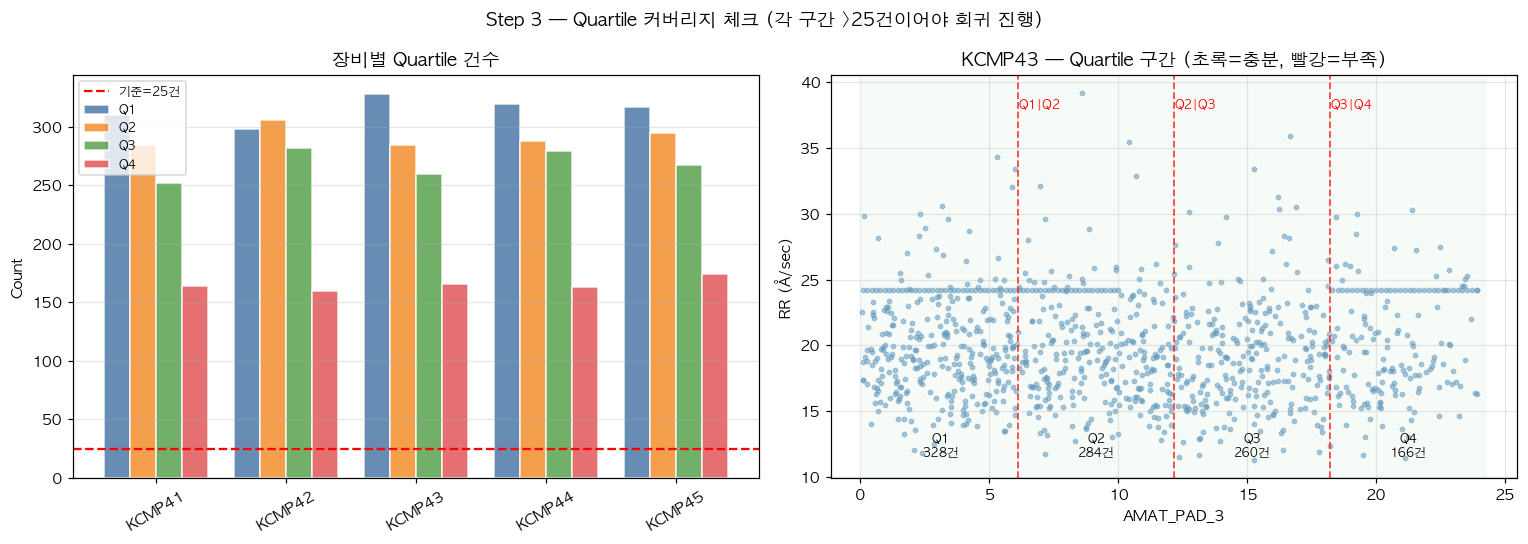

In [9]:
# ── 전체 장비 Quartile 커버리지 ──────────────────────────────────────
eq_recipe_list = sorted(temp_data4['eq_recipe'].unique())
qc_result = {}
for er in eq_recipe_list:
    td5 = temp_data4[temp_data4['eq_recipe'] == er]
    qc = pd.cut(td5[consumable_Para], bins=[part_min,part_1q,part_2q,part_3q,part_max],
                labels=['Q1','Q2','Q3','Q4']).value_counts()
    qc_result[er.split('//')[0]] = qc

qc_df = pd.DataFrame(qc_result).T[['Q1','Q2','Q3','Q4']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 3 — Quartile 커버리지 체크 (각 구간 >25건이어야 회귀 진행)', fontsize=12, fontweight='bold')

# ① Quartile 건수 heat-style bar
ax = axes[0]
x = np.arange(len(qc_df.index))
width = 0.2
qcolors = ['#4e79a7','#f28e2b','#59a14f','#e15759']
for j, q in enumerate(['Q1','Q2','Q3','Q4']):
    bars = ax.bar(x + j*width, qc_df[q], width, label=q,
                  color=qcolors[j], edgecolor='white', alpha=0.85)
ax.axhline(25, color='red', linewidth=1.5, linestyle='--', label='기준=25건')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(qc_df.index, rotation=30)
ax.set_title('장비별 Quartile 건수')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ② 대표 장비: 소모품 vs RR scatter + quartile 경계
ax = axes[1]
demo5 = temp_data5.sort_values(consumable_Para)
ax.scatter(demo5[consumable_Para], demo5['RR'], s=8, alpha=0.5,
           color='steelblue', label='data')
for xline, label in [(part_1q,'Q1|Q2'), (part_2q,'Q2|Q3'), (part_3q,'Q3|Q4')]:
    ax.axvline(xline, color='red', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.text(xline + 0.02, demo5['RR'].max() * 0.97, label, fontsize=8, color='red')

# 구간별 배경색
for seg_x, seg_x2, q, qc in zip(
    [part_min, part_1q, part_2q, part_3q],
    [part_1q,  part_2q, part_3q, part_max],
    ['Q1','Q2','Q3','Q4'],
    [quartile_counts['Q1'], quartile_counts['Q2'], quartile_counts['Q3'], quartile_counts['Q4']]
):
    color = '#d4efdf' if qc > 25 else '#fadbd8'
    ax.axvspan(seg_x, seg_x2, alpha=0.2, color=color)
    ax.text((seg_x+seg_x2)/2, demo5['RR'].min() * 1.02,
            f'{q}\n{qc}건', ha='center', fontsize=8)

ax.set_title(f'{DEMO_EQP} — Quartile 구간 (초록=충분, 빨강=부족)')
ax.set_xlabel(f'{consumable_Para}')
ax.set_ylabel('RR (Å/sec)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 4 — `_fit_lr()` : b1, b0 (기본 선형회귀)

```python
# REMOVAL_RATE.py  _fit_lr()
lr.fit(df[x_col].values.reshape(-1,1), df[y_col].values.reshape(-1,1))
b1 = round(lr.coef_[0][0],    4)   # 기울기: RR이 소모품 1 증가할 때 얼마나 변하는가
b0 = round(lr.intercept_[0],  4)   # 절편 : 소모품=0 일 때의 기준 RR

# 의미
# RR_예측 = b1 × consumable + b0
# b1 < 0 → 패드 마모될수록 RR 감소 (일반적)
# b0     → 새 패드 기준 RR
```

In [10]:
# ── _fit_lr() 실제 함수 호출 ─────────────────────────────────────────
lr = LinearRegression()
b1, b0 = Removal_Rate_Get._fit_lr(temp_data5, consumable_Para, 'RR', lr)

print(f'b1 = {b1}   (기울기: 소모품 1km 증가 시 RR 변화량)')
print(f'b0 = {b0}   (절편: 소모품=0 일 때 기준 RR)')
print(f'\n해석: 패드가 1km 마모될 때마다 RR이 {b1:.4f} Å/sec 변화')
print(f'      새 패드(소모=0) 기준 RR = {b0:.2f} Å/sec')

b1 = -0.0137   (기울기: 소모품 1km 증가 시 RR 변화량)
b0 = 19.8651   (절편: 소모품=0 일 때 기준 RR)

해석: 패드가 1km 마모될 때마다 RR이 -0.0137 Å/sec 변화
      새 패드(소모=0) 기준 RR = 19.87 Å/sec


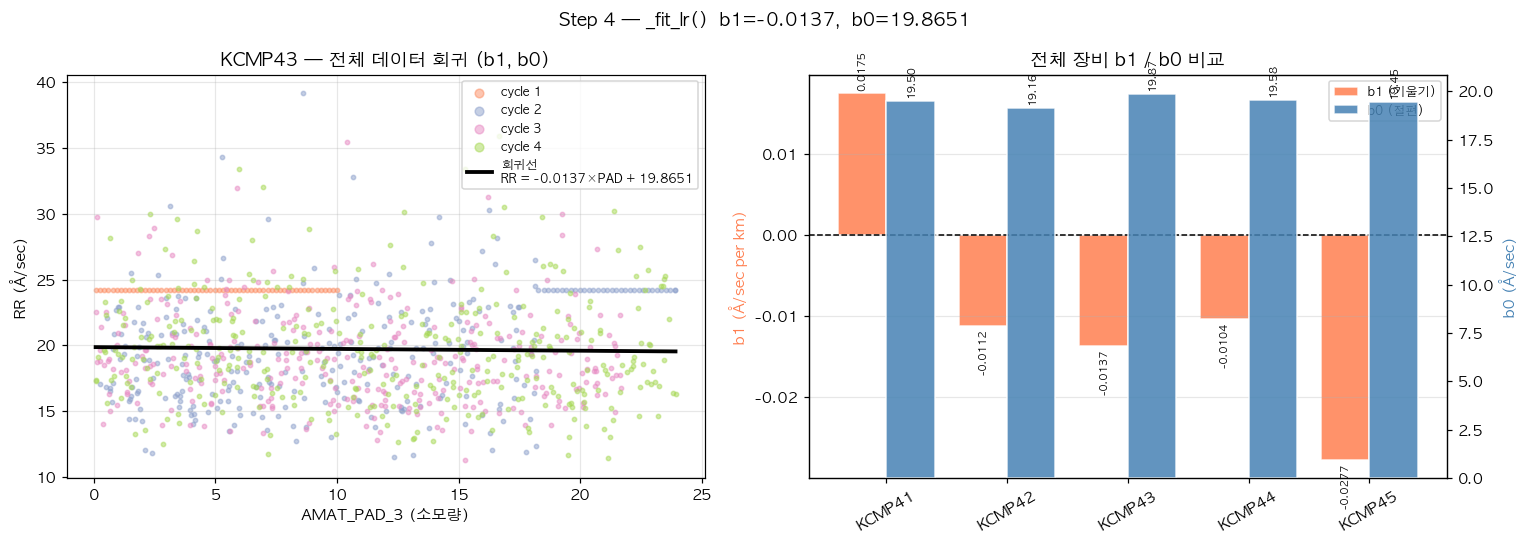

In [11]:
# ── b1/b0 회귀선 시각화 (사이클별 색상) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Step 4 — _fit_lr()  b1={b1},  b0={b0}', fontsize=12, fontweight='bold')

# ① 대표 장비 scatter + 회귀선
ax = axes[0]
for cyc in sorted(temp_data5['cycle'].unique()):
    c = temp_data5[temp_data5['cycle'] == cyc]
    ax.scatter(c[consumable_Para], c['RR'], s=8, alpha=0.5,
               color=cycle_colors[cyc % len(cycle_colors)], label=f'cycle {cyc}')

x_range = np.linspace(temp_data5[consumable_Para].min(),
                      temp_data5[consumable_Para].max(), 100)
y_pred  = b1 * x_range + b0
ax.plot(x_range, y_pred, color='black', linewidth=2.5,
        label=f'회귀선\nRR = {b1}×PAD + {b0}')

ax.set_title(f'{DEMO_EQP} — 전체 데이터 회귀 (b1, b0)')
ax.set_xlabel(f'{consumable_Para} (소모량)')
ax.set_ylabel('RR (Å/sec)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)

# ② 전체 장비 b1, b0 비교
ax = axes[1]
b1_all, b0_all, labels = [], [], []
for er in eq_recipe_list:
    td5_tmp = temp_data4[temp_data4['eq_recipe'] == er].copy()
    qc_tmp = pd.cut(td5_tmp[consumable_Para],
                    bins=[part_min,part_1q,part_2q,part_3q,part_max],
                    labels=['Q1','Q2','Q3','Q4']).value_counts()
    if (qc_tmp > 25).all():
        b1t, b0t = Removal_Rate_Get._fit_lr(td5_tmp, consumable_Para, 'RR', lr)
        b1_all.append(b1t); b0_all.append(b0t)
        labels.append(er.split('//')[0])

x_pos = np.arange(len(labels))
ax2 = ax.twinx()
bars1 = ax.bar(x_pos - 0.2, b1_all, 0.4, label='b1 (기울기)',
               color='coral', edgecolor='white', alpha=0.85)
bars2 = ax2.bar(x_pos + 0.2, b0_all, 0.4, label='b0 (절편)',
                color='steelblue', edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=30)
ax.set_ylabel('b1 (Å/sec per km)', color='coral')
ax2.set_ylabel('b0 (Å/sec)', color='steelblue')
ax.set_title('전체 장비 b1 / b0 비교')
ax.bar_label(bars1, fmt='%.4f', fontsize=7, rotation=90, padding=2)
ax2.bar_label(bars2, fmt='%.2f', fontsize=7, rotation=90, padding=2)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 5 — date × part 세그먼트 & `_fit_weighted()` : b1_weighted, b0_weighted

가중 회귀는 **최근 데이터에 더 많은 가중치**를 주는 방식입니다.  
먼저 최근 구간(`date_seg=4`)에 데이터가 충분한지 확인(`include_recent`)하고,  
조건이 충족되면 시간 그룹(group 0~4) 별로 반복 횟수를 다르게 하여 회귀합니다.

```python
# _process_models() 내부 — date × part 세그먼트 구성
temp_data5['group']         = pd.cut(temp_data5['Date'], bins=5, labels=False)     # 0~4
temp_data5['date_seg']      = pd.cut(temp_data5['Date'], bins=5, labels=[0,1,2,3,4]).astype(str)
temp_data5['part_seg']      = pd.cut(temp_data5[consumable_Para], bins=4, labels=[0,1,2,3]).astype(str)
temp_data5['date_part_seg'] = temp_data5['date_seg'] + '_' + temp_data5['part_seg']

recent_counts  = seg_counts[seg_counts['date_part_seg'].str.startswith('4_')]   # 최근 date 구간
include_recent = (len(recent_counts['date_part_seg'].unique()) == 4)             # 4개 part 구간 모두 존재
                 and (recent_counts['count'] > 25).all()                         # 각 25건 이상

# _fit_weighted() 내부
weight  = [1, 2, 3, 4, RR_Weight]   # group 0→1, 4→RR_Weight 배 반복
repeat  = temp_data5['group'].map(lambda g: weight[g])
X_w     = np.repeat(temp_data5[consumable_Para], repeat)   # 최근 행을 RR_Weight배 복제
y_w     = np.repeat(temp_data5['RR'],            repeat)
# → 최근 데이터가 가중치만큼 더 많이 반영된 회귀
```

In [12]:
# ── date × part 세그먼트 구성 (실제 코드 그대로) ────────────────────
temp_data5['group']         = pd.cut(temp_data5['Date'], bins=5, labels=False)
temp_data5['date_seg']      = pd.cut(temp_data5['Date'], bins=5, labels=[0,1,2,3,4]).astype(str)
temp_data5['part_seg']      = pd.cut(temp_data5[consumable_Para], bins=4, labels=[0,1,2,3]).astype(str)
temp_data5['date_part_seg'] = temp_data5['date_seg'] + '_' + temp_data5['part_seg']

seg_counts    = temp_data5.groupby(['eqp_id', 'date_part_seg']).size().reset_index(name='count')
recent_counts = seg_counts[seg_counts['date_part_seg'].str.startswith('4_')]
include_recent = (
    (len(recent_counts['date_part_seg'].unique()) == 4) and
    (recent_counts['count'] > 25).all()
)

print(f'include_recent = {include_recent}')
print(f'  최근 구간(date_seg=4) part별 건수:')
print(recent_counts[['date_part_seg','count']].to_string(index=False))

# ── _fit_weighted() 실제 함수 호출 ──────────────────────────────────
weight = [1, 2, 3, 4, RR_Weight]
wb1, wb0 = Removal_Rate_Get._fit_weighted(temp_data5, consumable_Para, weight, include_recent, lr)

print(f'\nweighted b1 = {wb1}  (기본 b1={b1})')
print(f'weighted b0 = {wb0}  (기본 b0={b0})')
if wb1 == '-':
    print('→ include_recent=False → 가중 회귀 미산출 ("-" 반환)')

include_recent = True
  최근 구간(date_seg=4) part별 건수:
date_part_seg  count
          4_0     36
          4_1     93
          4_2     78
          4_3     39

weighted b1 = -0.0307  (기본 b1=-0.0137)
weighted b0 = 21.1675  (기본 b0=19.8651)


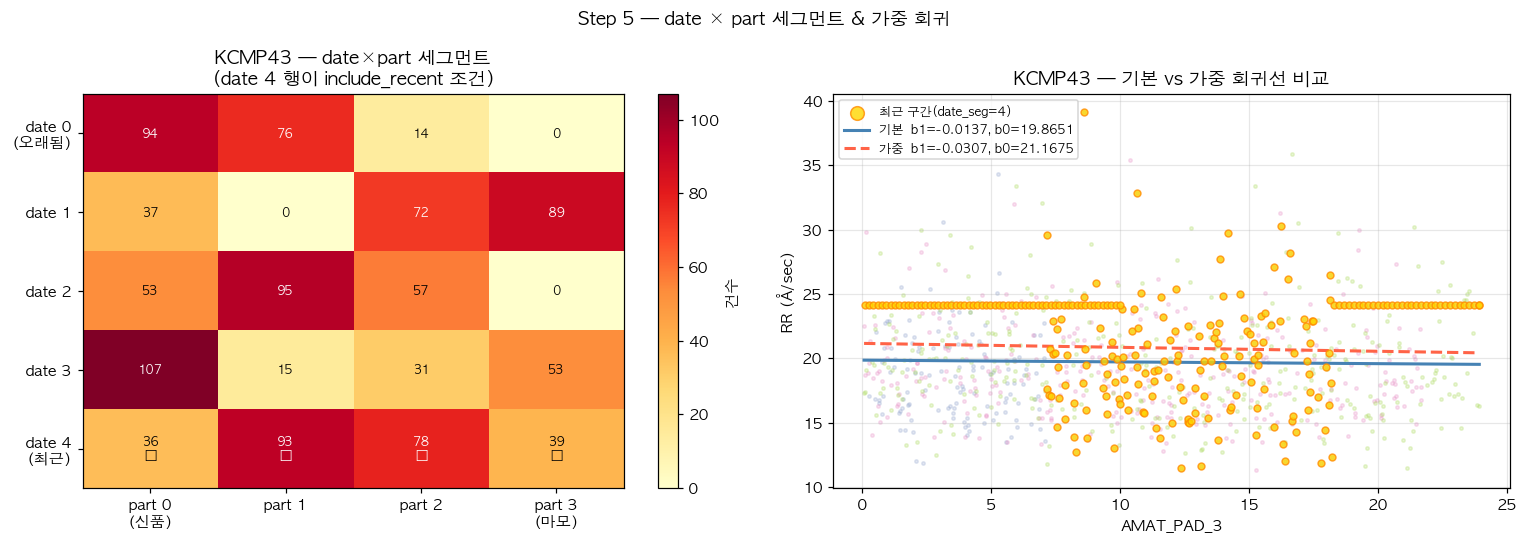

가중치 설정: group [0~4] = [1, 2, 3, 4, 30.0]
→ 최근(group 4) 데이터는 30배 복제하여 회귀에 반영


In [13]:
# ── 세그먼트 Heatmap + 가중 회귀선 비교 ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step 5 — date × part 세그먼트 & 가중 회귀', fontsize=12, fontweight='bold')

# ① 세그먼트 Heatmap (date_seg × part_seg 건수)
ax = axes[0]
pivot = temp_data5.groupby(['date_seg','part_seg']).size().unstack(fill_value=0)
pivot = pivot.reindex(index=['0','1','2','3','4'], columns=['0','1','2','3'], fill_value=0)

im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0)
plt.colorbar(im, ax=ax, label='건수')
ax.set_xticks(range(4)); ax.set_xticklabels(['part 0\n(신품)','part 1','part 2','part 3\n(마모)'])
ax.set_yticks(range(5)); ax.set_yticklabels(['date 0\n(오래됨)','date 1','date 2','date 3','date 4\n(최근)'])

for i in range(5):
    for j in range(4):
        n = pivot.values[i, j]
        color = 'white' if n > pivot.values.max() * 0.6 else 'black'
        ok = '\n✅' if (i == 4 and n > 25) else ('\n❌' if i == 4 else '')
        ax.text(j, i, f'{n}{ok}', ha='center', va='center', fontsize=8, color=color)

ax.set_title(f'{DEMO_EQP} — date×part 세그먼트\n(date 4 행이 include_recent 조건)')

# ② b vs b_weighted 회귀선 비교
ax = axes[1]
for cyc in sorted(temp_data5['cycle'].unique()):
    c = temp_data5[temp_data5['cycle'] == cyc]
    ax.scatter(c[consumable_Para], c['RR'], s=5, alpha=0.25,
               color=cycle_colors[cyc % len(cycle_colors)])

# 최근 데이터 강조 (group=4)
recent_pts = temp_data5[temp_data5['date_seg'] == '4']
ax.scatter(recent_pts[consumable_Para], recent_pts['RR'], s=20, alpha=0.8,
           color='gold', edgecolor='darkorange', zorder=5, label=f'최근 구간(date_seg=4)')

# 기본 회귀선
ax.plot(x_range, y_pred, color='steelblue', linewidth=2,
        label=f'기본  b1={b1}, b0={b0}')

# 가중 회귀선
if wb1 != '-':
    y_weighted = float(wb1) * x_range + float(wb0)
    ax.plot(x_range, y_weighted, color='tomato', linewidth=2, linestyle='--',
            label=f'가중  b1={wb1}, b0={wb0}')

ax.set_title(f'{DEMO_EQP} — 기본 vs 가중 회귀선 비교')
ax.set_xlabel(f'{consumable_Para}')
ax.set_ylabel('RR (Å/sec)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'가중치 설정: group [0~4] = {weight}')
print(f'→ 최근(group 4) 데이터는 {int(RR_Weight)}배 복제하여 회귀에 반영')

---
## Step 6 — `_fit_current()` : b1_current, b0_current

**현재 패드 사이클(cycle=1)** 의 최근 데이터로 실시간 회귀를 수행합니다.  
아래 **세 가지 조건을 모두 만족**해야만 산출됩니다.

```python
# _fit_current() 내부 — 조건 판별
count      = len(current_cycle)                          # 현재 사이클 데이터 수
time_delta = today_date - current_cycle['Date'].iloc[0]  # 첫 데이터 이후 경과 시간
min_count  = _get_pm_rank(EQPM_df, Maker, EQ, rcp_id)   # PM 이후 누적 웨이퍼 수

if not (
    (count > RR_Count)            and   # ① 현재 사이클 데이터 > RR_Count(50건)
    (time_delta < timedelta(hours=12)) and  # ② 첫 데이터 이후 12시간 이내
    (min_count >= 2)              # ③ PM 이후 웨이퍼 2장 이상 처리
):
    return '-', '-', '-'   # 조건 미충족 → current 미산출
```

> 샘플 데이터는 과거 데이터이므로 **조건 ②(12h 이내)** 를 충족하지 못해 `'-'` 가 반환됩니다.

In [14]:
# ── _get_current_cycle() 실제 함수 호출 ─────────────────────────────
current_cycle = Removal_Rate_Get._get_current_cycle(
    temp_data5, consumable_Para, RR_Period
)

# ── EQPM_df 구성 (_build_eqpm_df와 동일한 rank 계산 포함) ───────────
# Module._build_eqpm_df 로직 그대로 — PM 이후 EndLot 누적 웨이퍼 수(rank) 산출
from datetime import datetime, timedelta
EQPM_df = Get_data.EQPMGetData_HUB('M10', tuple([DEMO_EQP]), tuple([DEMO_RCP]))
EQPM_df = EQPM_df.sort_values(by=['EQP_ID', 'EVENT_TM']).reset_index(drop=True)

def compute_rank(group):
    # PM 이벤트 발생 시 rank를 0으로 리셋, EndLot/JobEnd마다 1씩 증가
    event_pm_index = group[group['EVENT_CD'].str.contains('PM')].index
    ranks = []
    current_rank = 0
    for idx in group.index:
        if idx in event_pm_index:
            current_rank = 0
        else:
            if group.loc[idx, 'EVENT_CD'] in ['EndLot', 'JobEnd']:
                current_rank += 1
        ranks.append(current_rank)
    return ranks

EQPM_df['rank'] = EQPM_df.groupby('EQP_ID').apply(
    lambda x: pd.Series(compute_rank(x))
).reset_index(level=0, drop=True).values.reshape(-1)
EQPM_df['EVENT_TM'] = pd.to_datetime(EQPM_df['EVENT_TM'])

# ── _fit_current() 실제 함수 호출 ───────────────────────────────────
Simul_Date, cur_b1, cur_b0 = Removal_Rate_Get._fit_current(
    current_cycle, consumable_Para, datetime.now(),
    RR_Count, EQPM_df, key['Maker'], DEMO_EQP, DEMO_RCP,
    wb1, wb0, b1, b0, RR_Period, lr
)

print(f'현재 사이클 (cycle=1) 데이터: {len(current_cycle)}건')
if not current_cycle.empty:
    elapsed = datetime.now() - current_cycle['Date'].iloc[0]
    print(f'  첫 데이터 이후 경과: {elapsed}')
print(f'\n조건 확인')
count_ok   = len(current_cycle) > RR_Count
time_ok    = not current_cycle.empty and (datetime.now() - current_cycle['Date'].iloc[0]) < timedelta(hours=12)
pm_rank    = int(EQPM_df[EQPM_df['EQP_ID']==DEMO_EQP].sort_values('EVENT_TM',ascending=False)['rank'].iloc[0]) if not EQPM_df.empty else 0
print(f'  ① count > {RR_Count:.0f}건:      {len(current_cycle)} > {RR_Count:.0f}  → {count_ok}')
print(f'  ② time_delta < 12h:  → {time_ok}  (샘플 데이터는 과거)')
print(f'  ③ PM rank >= 2:      rank={pm_rank}  → {pm_rank >= 2}')
print(f'\ncurrent_b1 = {cur_b1}  |  current_b0 = {cur_b0}  (조건 미충족 시 "-" 반환)')


현재 사이클 (cycle=1) 데이터: 60건
  첫 데이터 이후 경과: 0 days 15:07:26.743228

조건 확인
  ① count > 50건:      60 > 50  → True
  ② time_delta < 12h:  → False  (샘플 데이터는 과거)
  ③ PM rank >= 2:      rank=10  → True

current_b1 = -  |  current_b0 = -  (조건 미충족 시 "-" 반환)


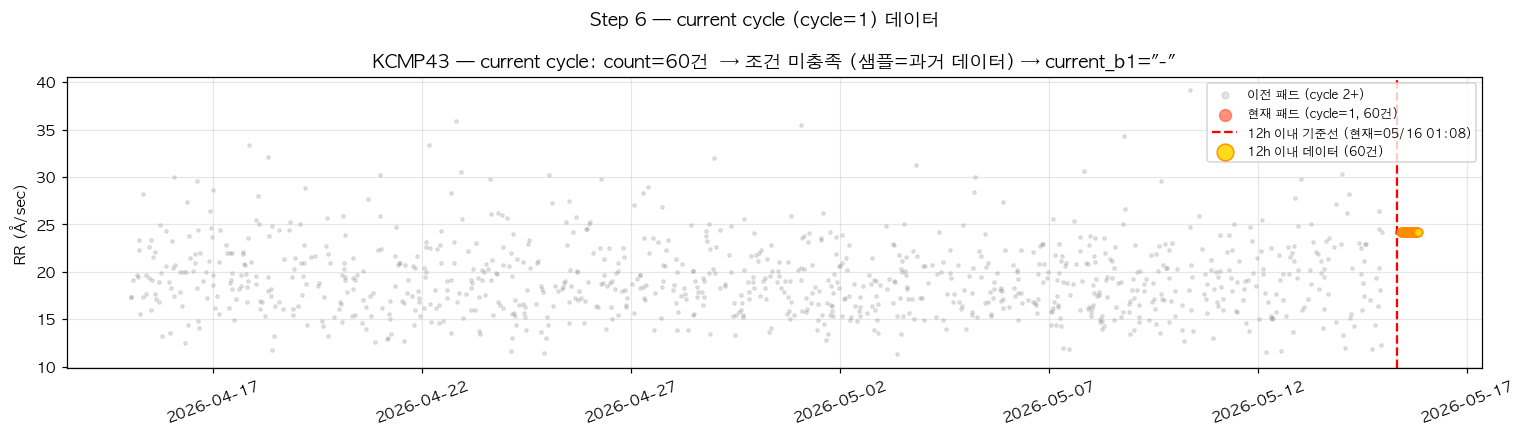

In [15]:
# ── current cycle 시각화 ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Step 6 — current cycle (cycle=1) 데이터', fontsize=12, fontweight='bold')

# 전체 데이터 (연한 색)
non_current = temp_data5[temp_data5['cycle'] != 1]
ax.scatter(non_current['Date'], non_current['RR'], s=5, alpha=0.2,
           color='gray', label='이전 패드 (cycle 2+)')

# 현재 사이클
if not current_cycle.empty:
    ax.scatter(current_cycle['Date'], current_cycle['RR'], s=15, alpha=0.7,
               color='tomato', label=f'현재 패드 (cycle=1, {len(current_cycle)}건)')

    # 현재 사이클이 12h 조건인지 표시
    last_date  = current_cycle['Date'].max()
    cutoff_12h = last_date - timedelta(hours=12)
    ax.axvline(cutoff_12h, color='red', linewidth=1.5, linestyle='--',
               label=f'12h 이내 기준선 (현재={datetime.now().strftime("%m/%d %H:%M")})')
    within_12h = current_cycle[current_cycle['Date'] >= cutoff_12h]
    if not within_12h.empty:
        ax.scatter(within_12h['Date'], within_12h['RR'], s=30, alpha=0.9,
                   color='gold', edgecolor='darkorange', zorder=5,
                   label=f'12h 이내 데이터 ({len(within_12h)}건)')

ax.set_title(f'{DEMO_EQP} — current cycle: count={len(current_cycle)}건  '
             f'→ 조건 미충족 (샘플=과거 데이터) → current_b1="-"')
ax.set_ylabel('RR (Å/sec)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=20)
ax.xaxis.set_major_locator(ticker.MaxNLocator(8))

plt.tight_layout()
plt.show()

---
## Step 7 — `_fit_if()` : if_b1, if_b0 (초기 마모 구간 회귀)

`Pad_Seperation` 이하 소모 구간에서만 회귀를 수행합니다.  
패드 **초기(신품~Pad_Seperation)** 구간의 RR 특성이 이후 구간과 다를 수 있기 때문입니다.

```python
# _fit_if() 내부
temp_data7 = temp_data5[temp_data5[consumable_Para] <= Pad_Seperation]  # IF 구간만

if len(temp_data7) < 100:           # 데이터 부족 → '-' 반환
    return '-', '-'

step      = Pad_Seperation / 4
if_counts = pd.cut(temp_data7[consumable_Para],
                   bins=[0, step, step*2, step*3, Pad_Seperation],
                   labels=['Q1','Q2','Q3','Q4']).value_counts()

if not (if_counts >= 25).all():     # IF 구간 내 4분위도 각 25건 이상이어야
    return '-', '-'

return _fit_lr(temp_data7, consumable_Para, 'RR', lr)  # IF 구간 회귀
```

In [16]:
# ── _fit_if() 실제 함수 호출 ─────────────────────────────────────────
if_b1, if_b0 = Removal_Rate_Get._fit_if(
    temp_data5, consumable_Para, Pad_Seperation, lr
)

# IF 구간 데이터 확인
if pd.notna(Pad_Seperation):
    td_if = temp_data5[temp_data5[consumable_Para] <= float(Pad_Seperation)]
    step  = float(Pad_Seperation) / 4
    if_qc = pd.cut(
        td_if[consumable_Para],
        bins=[0, step, step*2, step*3, float(Pad_Seperation)],
        labels=['Q1','Q2','Q3','Q4']
    ).value_counts()
    print(f'Pad_Seperation = {Pad_Seperation}  →  IF 구간: {consumable_Para} ≤ {Pad_Seperation}')
    print(f'IF 구간 데이터: {len(td_if)}건')
    print('IF 구간 Quartile 건수:')
    for q, n in if_qc.items():
        ok = '✅' if n >= 25 else '❌'
        print(f'  {q}: {n:4d}건  {ok}')

print(f'\nif_b1 = {if_b1}')
print(f'if_b0 = {if_b0}')

Pad_Seperation = 3  →  IF 구간: AMAT_PAD_3 ≤ 3
IF 구간 데이터: 152건
IF 구간 Quartile 건수:
  Q2:   42건  ✅
  Q3:   41건  ✅
  Q4:   37건  ✅
  Q1:   32건  ✅

if_b1 = 0.1797
if_b0 = 19.7243


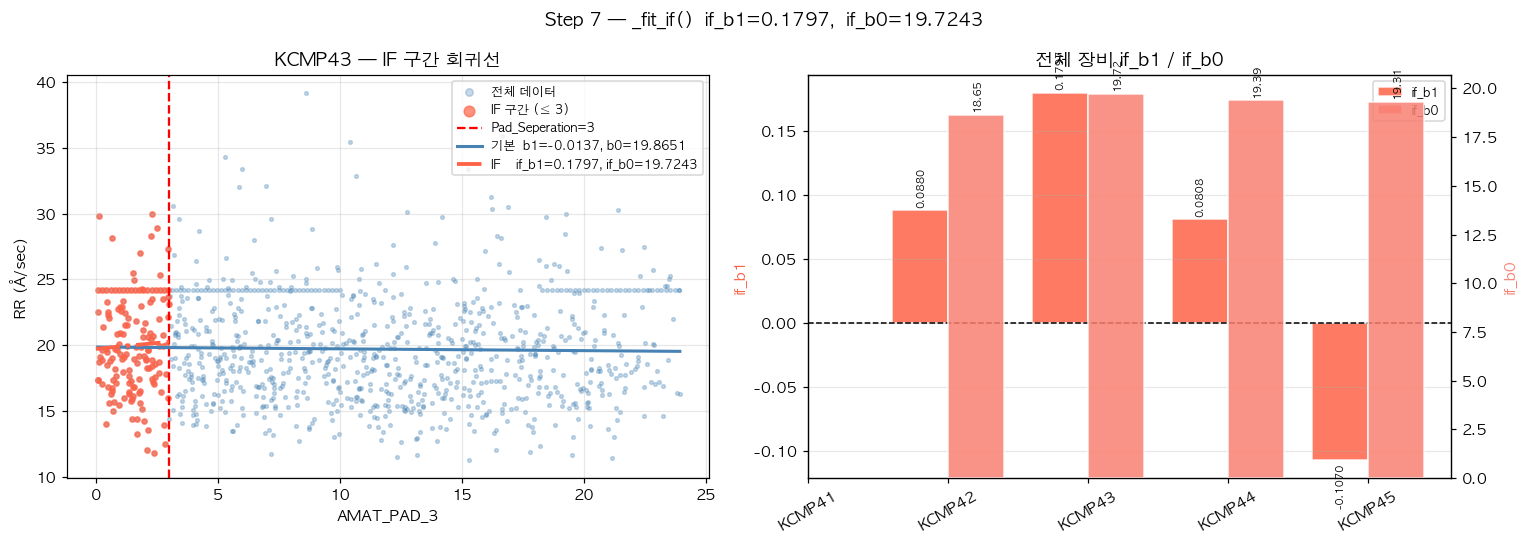

In [17]:
# ── IF 구간 회귀선 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Step 7 — _fit_if()  if_b1={if_b1},  if_b0={if_b0}', fontsize=12, fontweight='bold')

# ① 대표 장비 — 전체 + IF 구간 + 회귀선 3개 비교
ax = axes[0]
ax.scatter(temp_data5[consumable_Para], temp_data5['RR'],
           s=6, alpha=0.3, color='steelblue', label='전체 데이터')

if pd.notna(Pad_Seperation):
    td_if_plot = temp_data5[temp_data5[consumable_Para] <= float(Pad_Seperation)]
    ax.scatter(td_if_plot[consumable_Para], td_if_plot['RR'],
               s=12, alpha=0.7, color='tomato', label=f'IF 구간 (≤ {Pad_Seperation})')
    ax.axvline(float(Pad_Seperation), color='red', linewidth=1.5, linestyle='--',
               label=f'Pad_Seperation={Pad_Seperation}')

# 기본 회귀선 (전체)
ax.plot(x_range, y_pred, color='steelblue', linewidth=2,
        label=f'기본  b1={b1}, b0={b0}')

# IF 회귀선
if if_b1 != '-' and pd.notna(Pad_Seperation):
    x_if = np.linspace(0, float(Pad_Seperation), 50)
    y_if = float(if_b1) * x_if + float(if_b0)
    ax.plot(x_if, y_if, color='tomato', linewidth=2.5, linestyle='-.',
            label=f'IF    if_b1={if_b1}, if_b0={if_b0}')

ax.set_title(f'{DEMO_EQP} — IF 구간 회귀선')
ax.set_xlabel(f'{consumable_Para}')
ax.set_ylabel('RR (Å/sec)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)

# ② 전체 장비 if_b1 비교
ax = axes[1]
if_b1_all, if_b0_all, if_labels = [], [], []
for er in eq_recipe_list:
    td5_tmp = temp_data4[temp_data4['eq_recipe'] == er].copy()
    td5_tmp['group'] = pd.cut(td5_tmp['Date'], bins=5, labels=False)
    ib1, ib0 = Removal_Rate_Get._fit_if(td5_tmp, consumable_Para, Pad_Seperation, lr)
    if_b1_all.append(float(ib1) if ib1 != '-' else np.nan)
    if_b0_all.append(float(ib0) if ib0 != '-' else np.nan)
    if_labels.append(er.split('//')[0])

x_pos = np.arange(len(if_labels))
ax2 = ax.twinx()
bars1 = ax.bar(x_pos - 0.2, if_b1_all, 0.4, label='if_b1',
               color='tomato', edgecolor='white', alpha=0.85)
bars2 = ax2.bar(x_pos + 0.2, if_b0_all, 0.4, label='if_b0',
                color='salmon', edgecolor='white', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(if_labels, rotation=30)
ax.set_ylabel('if_b1', color='tomato')
ax2.set_ylabel('if_b0', color='salmon')
ax.set_title('전체 장비 if_b1 / if_b0')
ax.bar_label(bars1, fmt='%.4f', fontsize=7, rotation=90, padding=2)
ax2.bar_label(bars2, fmt='%.2f', fontsize=7, rotation=90, padding=2)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 최종 결과 — 전체 계수 요약

| 계수 | 설명 | 조건 |
|------|------|------|
| **b1, b0** | 전체 데이터 기본 회귀 | quartile 각 >25건 |
| **b1_weighted, b0_weighted** | 최근 구간 가중 회귀 | include_recent=True |
| **b1_current, b0_current** | 현재 사이클 실시간 회귀 | 12h 이내 & RR_Count 초과 & PM rank ≥ 2 |
| **if_b1, if_b0** | PAD ≤ Pad_Seperation 구간 회귀 | IF 구간 quartile 각 ≥25건 |

In [18]:
# ── 전체 장비 결과 테이블 ─────────────────────────────────────────────
from Common.MongoDB_Control import _STORE, mongodb_controller
from Common.Module import Module_Get
import Common.OFFSET as _offset_mod

# load_rr_data Mock
def _noop(mdf, Fab, LC, OD, apc_list, mu, mdb):
    out = mdf.copy()
    for p in apc_list: out[f'{p}_B1']=0.80; out[f'{p}_B0']=5.00
    return out
_offset_mod.OFFSET_Get.load_rr_data = staticmethod(_noop)

# 이전 결과 초기화 후 compute_rr 전체 실행
for k in [k for k in _STORE if 'Removal_Rate' in k]:
    _STORE[k] = []

mico_key = mico.copy()
mico_key['Group_Name'] = mico_key['Group_Name'].fillna('not_group')

# merge_df_orig: load_pre_thk_data 호출 전 원본 (pre_oper_time / request_dtts 컬럼 존재)
# compute_removal_rate 내부에서 load_pre_thk_data를 다시 호출하므로 원본을 전달해야 함
print('--- compute_removal_rate 실행 ---')
Module_Get.compute_removal_rate(merge_df_orig.copy(), mico_key, pol_type=3)

# 결과 수집
rr_records = []
for k, v in _STORE.items():
    if 'Removal_Rate' in k and v:
        rr_records.extend(v)

rr_result = pd.DataFrame(rr_records)
for col in ['b1','b0','b1_weighted','b0_weighted','if_b1','if_b0']:
    if col in rr_result.columns:
        rr_result[col] = pd.to_numeric(rr_result[col], errors='coerce')

print(f'\n최종 결과: {len(rr_result)}건')
show_cols = [c for c in ['EQ','Recipe_ID','Count','b1','b0','b1_weighted','b0_weighted',
                          'b1_current','b0_current','if_b1','if_b0'] if c in rr_result.columns]
display(rr_result[show_cols])


--- compute_removal_rate 실행 ---

  [Removal Rate] M10 | LC | M1 CU CMP 시작
    Pre_Thk_VM 로드 중 ...
    [Excel 캐시] LC_M1_CU_CMP_M10.xlsx 로드
    → AMAT_POST_OCD_AVG_VM: 20844/20844 매칭
    APC_Para=P3 | Recipe_ID=E2_M1CU_R12_TSV.CAS | Thk_Para=AMAT_POST_OCD_AVG
    [MongoDB mock] insert_row → MICO_Removal_Rate_LC_M1 CU CMP_M10: {'EQ': 'KCMP43', 'Recipe_ID': 'E2_M1CU_R12_TSV.CAS', 'Count': 1039, 'b1': '-0.0137', 'b0': '19.8651', 'b1_weighted': '-0.0307', 'b0_weighted': '21.1675', 'if_b1': '0.1797', 'if_b0': '19.7243'}
    [MongoDB mock] insert_row → MICO_Removal_Rate_LC_M1 CU CMP_M10: {'EQ': 'KCMP42', 'Recipe_ID': 'E2_M1CU_R12_TSV.CAS', 'Count': 1046, 'b1': '-0.0112', 'b0': '19.1610', 'if_b1': '0.0880', 'if_b0': '18.6487'}
    [MongoDB mock] insert_row → MICO_Removal_Rate_LC_M1 CU CMP_M10: {'EQ': 'KCMP41', 'Recipe_ID': 'E2_M1CU_R12_TSV.CAS', 'Count': 1010, 'b1': '0.0175', 'b0': '19.5028', 'b1_weighted': '-0.0105', 'b0_weighted': '20.0545'}
    [MongoDB mock] insert_row → MICO_Removal_Rate_L

,EQ,Recipe_ID,Count,b1,b0,b1_weighted,b0_weighted,if_b1,if_b0
0,KCMP43,E2_M1CU_R12_TSV.CAS,1039,-0.0137,19.8651,-0.0307,21.1675,0.1797,19.7243
1,KCMP42,E2_M1CU_R12_TSV.CAS,1046,-0.0112,19.1610,NaN,NaN,0.0880,18.6487
2,KCMP41,E2_M1CU_R12_TSV.CAS,1010,0.0175,19.5028,-0.0105,20.0545,NaN,NaN
3,KCMP44,E2_M1CU_R12_TSV.CAS,1049,-0.0104,19.5762,-0.0316,20.1153,0.0808,19.3880
4,KCMP45,E2_M1CU_R12_TSV.CAS,1053,-0.0277,19.4525,0.0414,17.9843,-0.1070,19.3139


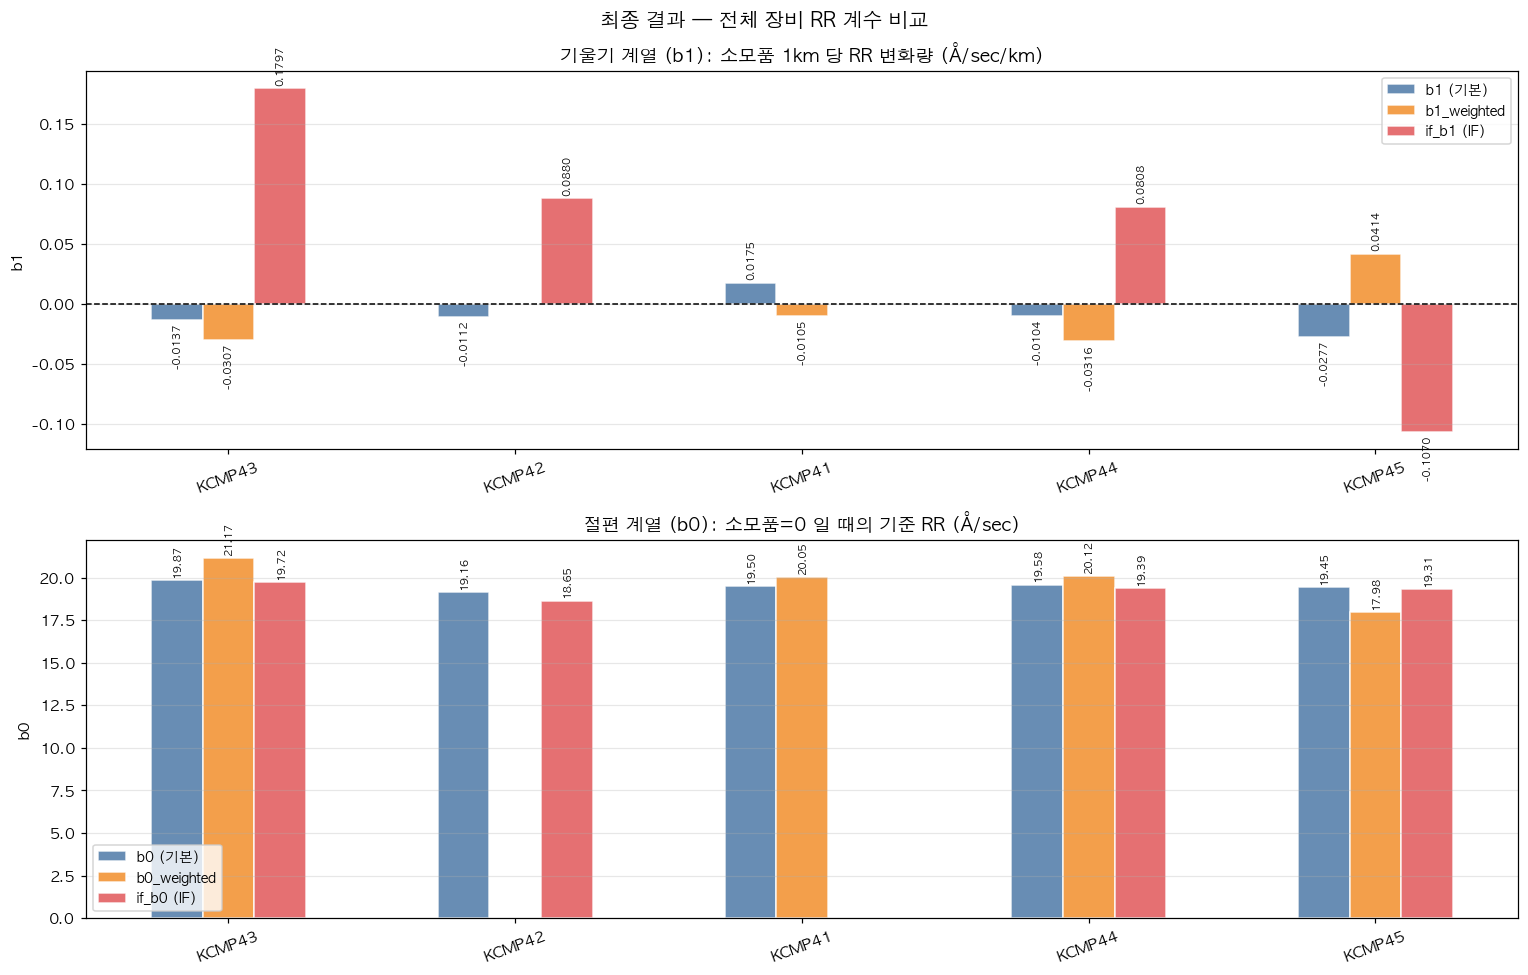

In [19]:
# ── 전체 장비 모든 계수 비교 차트 ────────────────────────────────────
if not rr_result.empty and 'EQ' in rr_result.columns:

    eq_labels = rr_result['EQ'].tolist()
    x_pos = np.arange(len(eq_labels))
    width = 0.18

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))
    fig.suptitle('최종 결과 — 전체 장비 RR 계수 비교', fontsize=13, fontweight='bold')

    # ① 기울기(b1) 계열
    ax = axes[0]
    coef_pairs = [
        ('b1',          'b1 (기본)',    '#4e79a7'),
        ('b1_weighted', 'b1_weighted',  '#f28e2b'),
        ('if_b1',       'if_b1 (IF)',   '#e15759'),
    ]
    for j, (col, label, color) in enumerate(coef_pairs):
        if col in rr_result.columns:
            vals = rr_result[col].tolist()
            bars = ax.bar(x_pos + (j - 1) * width, vals, width,
                          label=label, color=color, edgecolor='white', alpha=0.85)
            ax.bar_label(bars, fmt='%.4f', fontsize=7, rotation=90, padding=2)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_xticks(x_pos); ax.set_xticklabels(eq_labels, rotation=20)
    ax.set_title('기울기 계열 (b1): 소모품 1km 당 RR 변화량 (Å/sec/km)')
    ax.set_ylabel('b1')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # ② 절편(b0) 계열
    ax = axes[1]
    coef_pairs0 = [
        ('b0',          'b0 (기본)',    '#4e79a7'),
        ('b0_weighted', 'b0_weighted',  '#f28e2b'),
        ('if_b0',       'if_b0 (IF)',   '#e15759'),
    ]
    for j, (col, label, color) in enumerate(coef_pairs0):
        if col in rr_result.columns:
            vals = rr_result[col].tolist()
            bars = ax.bar(x_pos + (j - 1) * width, vals, width,
                          label=label, color=color, edgecolor='white', alpha=0.85)
            ax.bar_label(bars, fmt='%.2f', fontsize=7, rotation=90, padding=2)
    ax.set_xticks(x_pos); ax.set_xticklabels(eq_labels, rotation=20)
    ax.set_title('절편 계열 (b0): 소모품=0 일 때의 기준 RR (Å/sec)')
    ax.set_ylabel('b0')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()